In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

print("PyTorch version:", torch.__version__)
print("Setup successful!")

PyTorch version: 2.12.0
Setup successful!


In [2]:
labels = pd.read_csv("../data/train/labels.csv")

labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [3]:
frame = labels.iloc[0]["frame"]

image_name = f"{int(frame):06d}.jpg"

image_path = f"../data/train/rgb-front/{image_name}"

print(image_path)

../data/train/rgb-front/000000.jpg


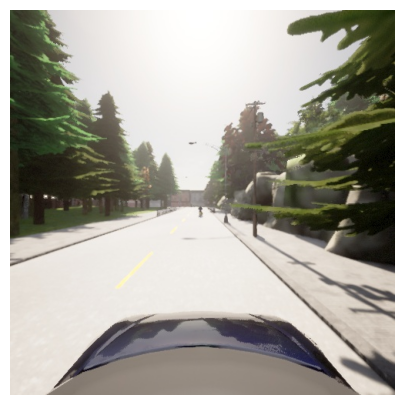

In [4]:
img = Image.open(image_path)

plt.figure(figsize=(8,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [5]:
train_labels = pd.read_csv("../data/train/labels.csv")
val_labels = pd.read_csv("../data/validation/labels.csv")
test_labels = pd.read_csv("../data/test/labels.csv")

print("Training images:", len(train_labels))
print("Validation images:", len(val_labels))
print("Test images:", len(test_labels))

Training images: 7200
Validation images: 3600
Test images: 3600


In [6]:
print("Pedestrian Distribution")
print(train_labels["has_pedestrian"].value_counts())

print("\nTraffic Light Distribution")
print(train_labels["has_traffic_light"].value_counts())

print("\nVehicle Distribution")
print(train_labels["has_vehicle"].value_counts())

Pedestrian Distribution
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

Traffic Light Distribution
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64

Vehicle Distribution
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


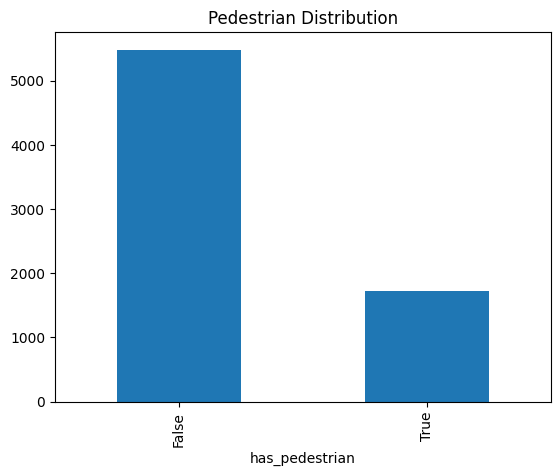

In [7]:
train_labels["has_pedestrian"].value_counts().plot(kind="bar", title="Pedestrian Distribution")
plt.show()

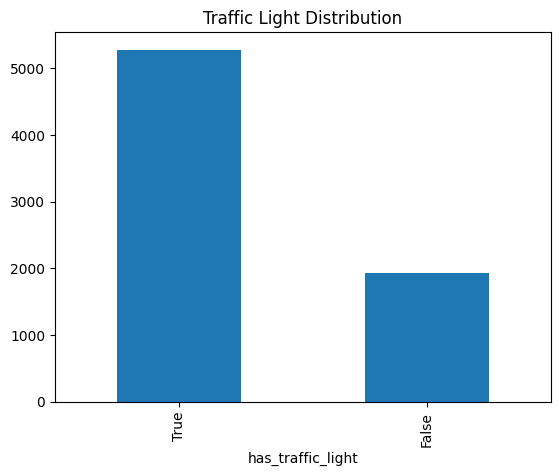

In [8]:
train_labels["has_traffic_light"].value_counts().plot(kind="bar", title="Traffic Light Distribution")
plt.show()

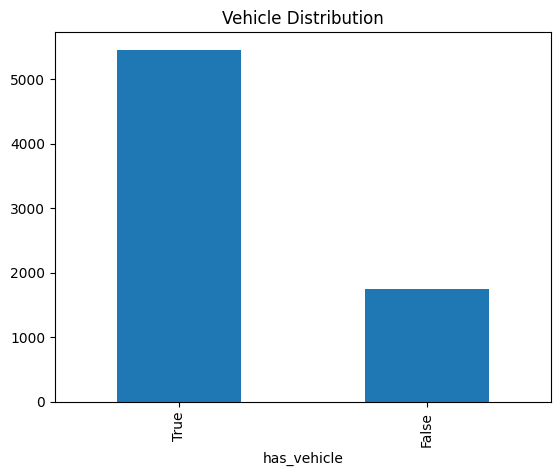

In [9]:
train_labels["has_vehicle"].value_counts().plot(kind="bar", title="Vehicle Distribution")
plt.show()

In [10]:
train_labels[[
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]].value_counts()

has_pedestrian  has_traffic_light  has_vehicle
False           True               True           3040
True            True               True           1125
False           False              True           1063
                True               False           832
                False              False           547
True            True               False           279
                False              True            230
                                   False            84
Name: count, dtype: int64

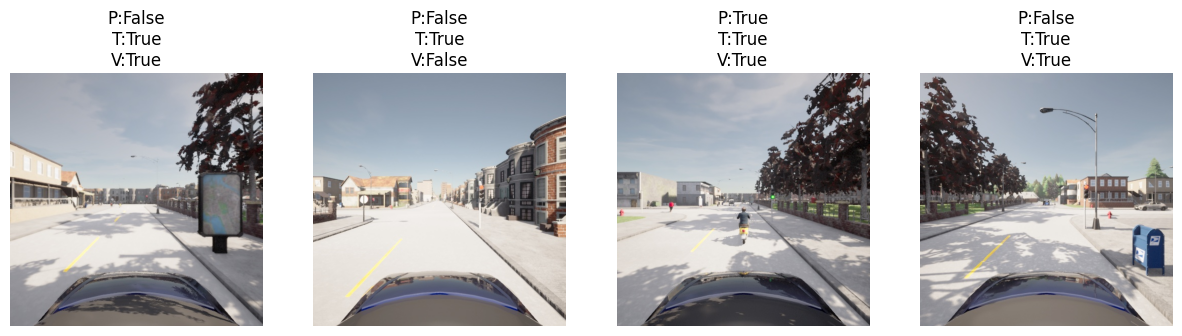

In [11]:
sample = train_labels.sample(4)

fig, axes = plt.subplots(1, 4, figsize=(15,5))

for ax, (_, row) in zip(axes, sample.iterrows()):

    frame = row["frame"]

    image_name = f"{int(frame):06d}.jpg"

    image_path = f"../data/train/rgb-front/{image_name}"

    img = Image.open(image_path)

    ax.imshow(img)

    title = f"P:{row['has_pedestrian']}\nT:{row['has_traffic_light']}\nV:{row['has_vehicle']}"

    ax.set_title(title)

    ax.axis("off")

plt.show()

In [12]:
train_labels["has_pedestrian"].value_counts()

has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

In [13]:
train_labels["has_traffic_light"].value_counts()

has_traffic_light
True     5276
False    1924
Name: count, dtype: int64

In [14]:
train_labels["has_vehicle"].value_counts()

has_vehicle
True     5458
False    1742
Name: count, dtype: int64